<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_01(Dataset%20_01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA of Retail Store Sales** [Dataset link](https://https://www.kaggle.com/datasets?search=retail+sales)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df= pd.read_csv("/content/store_sales.csv")
print("shape :", df.shape)
df.head()

shape : (5000, 11)


,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [ ]:
print("missing values: \n",df.isnull().sum())

missing values: 
 CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64


In [ ]:
print("duplicate values:\n",df.duplicated().sum())

duplicate values:
 0


**Statistical Analysis**

In [ ]:
print(df.describe())

        CustomerID          Age       Amount   ItemRating  DiscountApplied(%)  \
count  5000.000000  5000.000000  5000.000000  5000.000000         5000.000000   
mean   2500.500000    45.224800   285.090522     3.784160           14.983600   
std    1443.520003    14.564995   551.454382     0.681796            5.988063   
min       1.000000    20.000000     5.080000     1.100000            0.000000   
25%    1250.750000    33.000000    70.547500     3.300000           11.000000   
50%    2500.500000    45.000000   122.485000     3.800000           15.000000   
75%    3750.250000    58.000000   184.535000     4.300000           19.000000   
max    5000.000000    70.000000  2997.940000     5.000000           36.000000   

       PreviousPurchases  
count        5000.000000  
mean            5.008800  
std             2.194285  
min             0.000000  
25%             3.000000  
50%             5.000000  
75%             6.000000  
max            13.000000  


**Time series analysis-Sales by Season**

In [ ]:
season_sale=df.groupby("Season")["Amount"].sum().sort_values(ascending=False)
season_sale
print(season_sale)

Season
Spring    376029.40
Winter    354884.96
Summer    350860.36
Autumn    343677.89
Name: Amount, dtype: float64


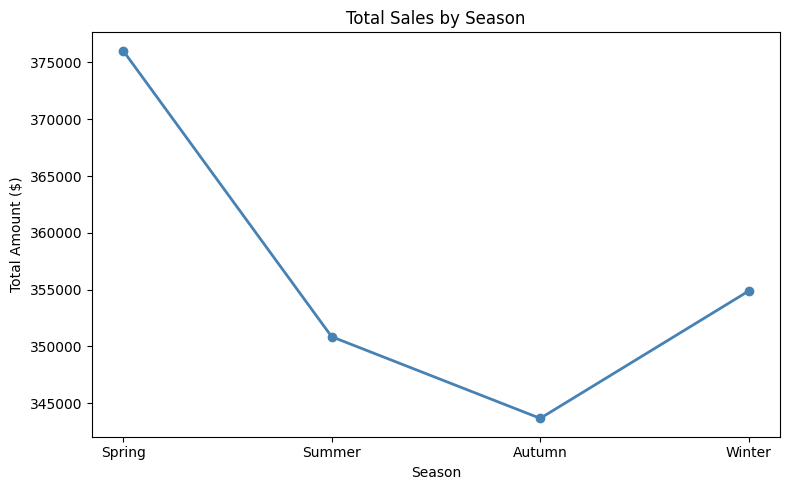

In [ ]:
#Line plot of sales by season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_sales_ordered = df.groupby('Season')['Amount'].sum().reindex(season_order)

plt.figure(figsize=(8, 5))
plt.plot(season_order, season_sales_ordered.values, marker='o', color='steelblue', linewidth=2)
plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Amount ($)")
plt.tight_layout()
plt.show()

**Customer and product analysis**

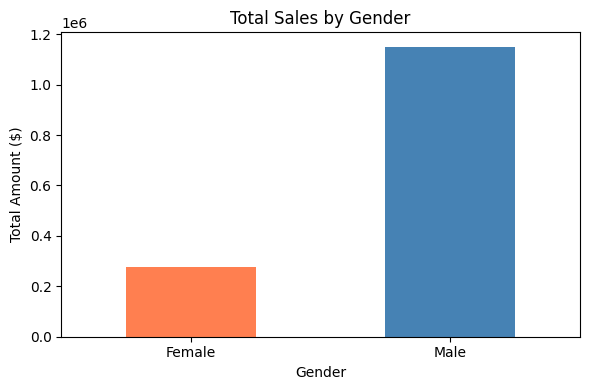

In [ ]:
#sales by gender
gender_sales=df.groupby('Gender')['Amount'].sum()
gender_sales.plot(kind='bar', color=['coral','steelblue'],figsize=(6,4))
plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
num_male_customers = df[df['Gender'] == 'Male'].shape[0]
print(f"Number of Male Customers: {num_male_customers}")

Number of Male Customers: 2496


In [ ]:
num_female_customers = df[df['Gender'] == 'Female'].shape[0]
print(f"Number of Female Customers: {num_female_customers}")

Number of Female Customers: 2504


In [ ]:
average_amount_by_gender = df.groupby('Gender')['Amount'].mean()
print("Average amount spent per transaction by Gender:")
print(average_amount_by_gender)

Average amount spent per transaction by Gender:
Gender
Female    110.119269
Male      460.622580
Name: Amount, dtype: float64


Total sales by category and gender:
Category  Accessories    Beauty  Electronics  Footwear  Groceries      Home  \
Gender                                                                        
Female       47633.83  43887.06         0.00  68669.12    7208.50  23208.36   
Male             0.00      0.00    895402.35  72473.12    6807.46  23165.86   

Category  Mens Clothing    Sports  Womens Clothing  
Gender                                              
Female             0.00  23413.37         61718.41  
Male           59680.43  92184.74             0.00  


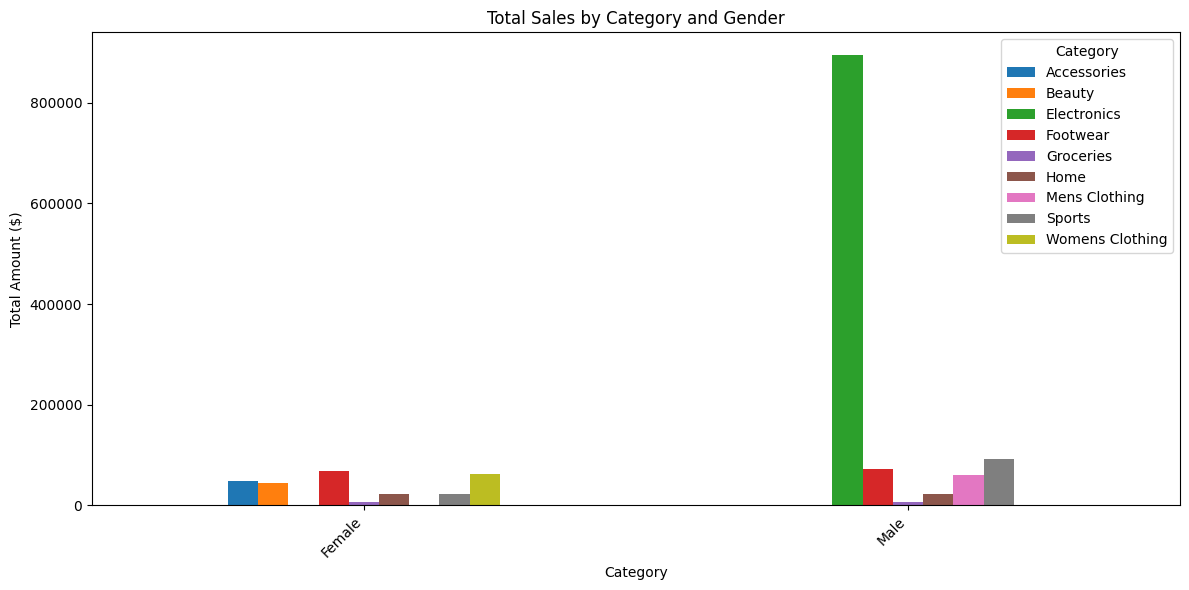

In [ ]:
category_by_gender = df.groupby(['Gender', 'Category'])['Amount'].sum().unstack(fill_value=0)
print("Total sales by category and gender:")
print(category_by_gender)

category_by_gender.plot(kind='bar', figsize=(12, 6))
plt.title('Total Sales by Category and Gender')
plt.ylabel('Total Amount ($)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
male_purchases = set(df[df['Gender'] == 'Male']['ItemPurchased'].unique())
female_purchases = set(df[df['Gender'] == 'Female']['ItemPurchased'].unique())

common_purchases = male_purchases.intersection(female_purchases)

print("Products purchased by both male and female customers:")
for item in common_purchases:
    print(f"- {item}")

Products purchased by both male and female customers:
- Snacks
- Jeans
- Beverages
- Cooking Oil
- Rice Pack
- Sneakers
- Sandals
- Kitchen Set
- Yoga Mat
- Curtains
- Lamp
- Dumbbells
- Football
- Formal Shoes


Average Discount Applied by Gender:
Gender
Female    15.033147
Male      14.933894
Name: DiscountApplied(%), dtype: float64


/tmp/ipykernel_1239/786751774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='DiscountApplied(%)', data=df, palette='viridis')


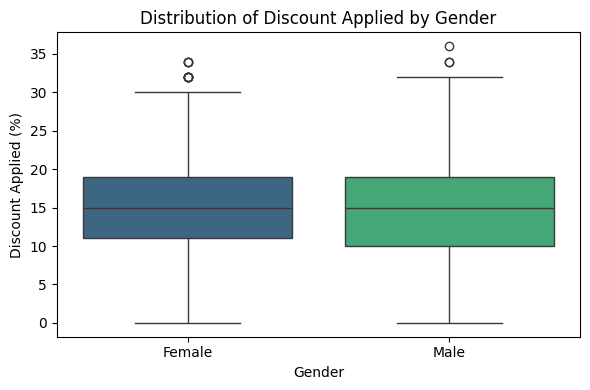

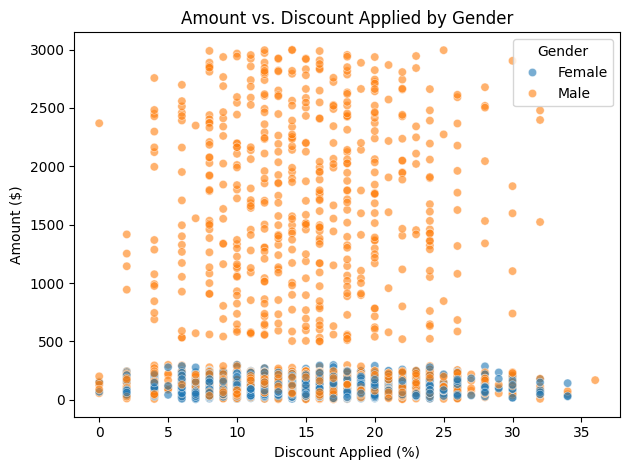

In [ ]:
discount_impact_gender = df.groupby('Gender')['DiscountApplied(%)'].mean()
print("Average Discount Applied by Gender:")
print(discount_impact_gender)

plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='DiscountApplied(%)', data=df, palette='viridis')
plt.title('Distribution of Discount Applied by Gender')
plt.ylabel('Discount Applied (%)')
plt.tight_layout()
plt.show()

sns.scatterplot(x='DiscountApplied(%)', y='Amount', hue='Gender', data=df, alpha=0.6)
plt.title('Amount vs. Discount Applied by Gender')
plt.xlabel('Discount Applied (%)')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

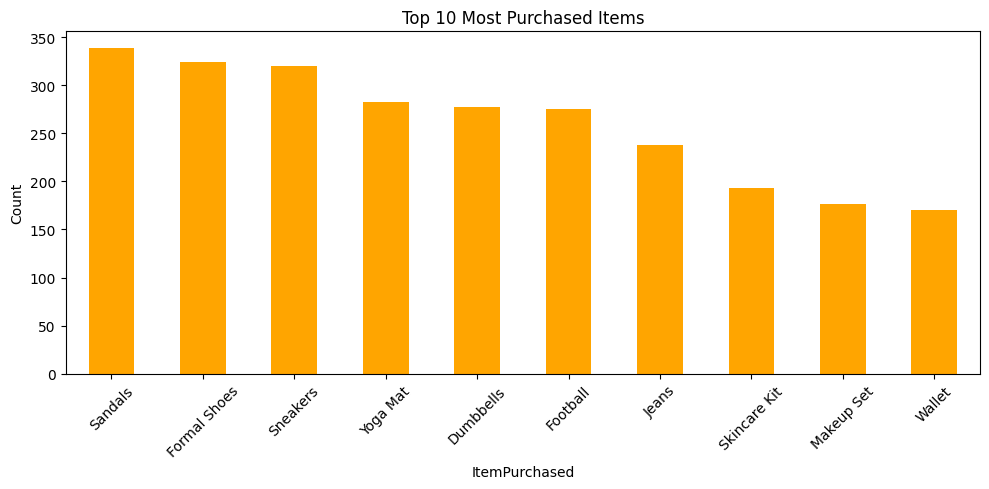

In [ ]:
#Top 10 most purchased items
top_items = df['ItemPurchased'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_items.plot(kind='bar', color='orange')
plt.title("Top 10 Most Purchased Items")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

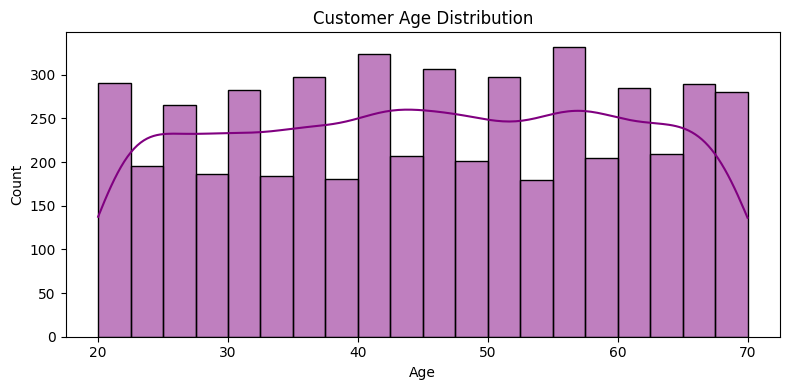

In [ ]:
#Age distribution of customers
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

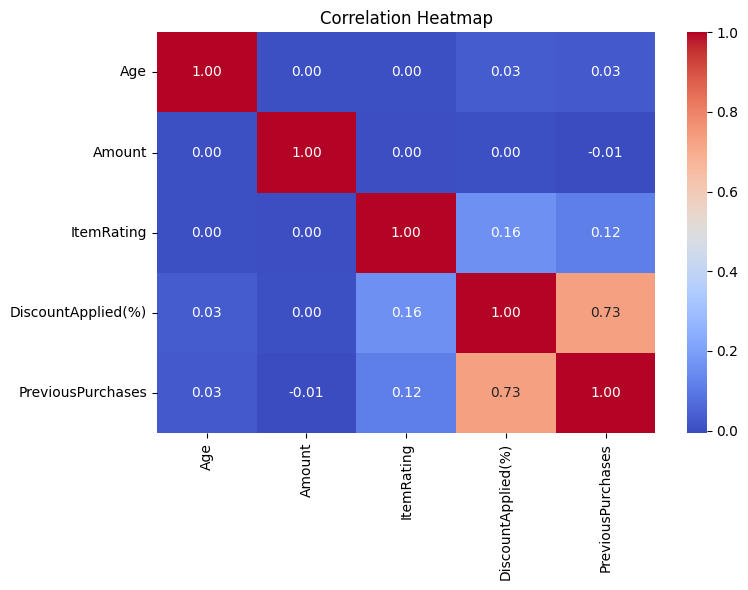

In [ ]:
#Heatmap of numeric columns
plt.figure(figsize=(8, 6))
numeric_df = df[['Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

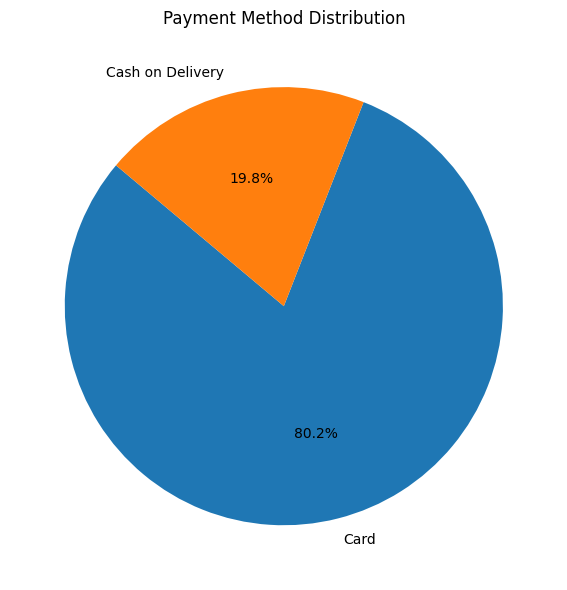

In [ ]:
#Payment method pie chart
payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment.values, labels=payment.index, autopct='%1.1f%%', startangle=140)
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()

In [ ]:
#Printing actionable insights
top_cat = df.groupby('Category')['Amount'].sum().idxmax()
top_season = df.groupby('Season')['Amount'].sum().idxmax()
top_payment = df['PaymentMethod'].value_counts().idxmax()
avg_rating = round(df['ItemRating'].mean(), 2)

print(f"1. Top Revenue Category   : {top_cat} — focus marketing here")
print(f"2. Best Sales Season      : {top_season} — plan promotions accordingly")
print(f"3. Preferred Payment      : {top_payment} — ensure smooth experience")
print(f"4. Avg Item Rating        : {avg_rating}/5 — track low-rated items")
print(f"5. Discount & Sales Corr  : Check heatmap — optimize discount strategy")

1. Top Revenue Category   : Electronics — focus marketing here
2. Best Sales Season      : Spring — plan promotions accordingly
3. Preferred Payment      : Card — ensure smooth experience
4. Avg Item Rating        : 3.78/5 — track low-rated items
5. Discount & Sales Corr  : Check heatmap — optimize discount strategy
